### 1. Feature Map and Dimension

**Feature Map $\phi(x)$**

For an input vector $x \in \mathbb{R}^4$ where $x = \begin{bmatrix} x_1 & x_2 & x_3 & x_4 \end{bmatrix}^T$, a polynomial of degree at most 2 requires a constant term, linear terms, squared terms, and cross-product (interaction) terms.
The feature map $\phi(x)$ is defined as:

$$
\phi(x) = \begin{bmatrix} 
1 & x_1 & x_2 & x_3 & x_4 & x_1^2 & x_2^2 & x_3^2 & x_4^2 & x_1x_2 & x_1x_3 & x_1x_4 & x_2x_3 & x_2x_4 & x_3x_4 
\end{bmatrix}^T
$$

**Dimension of $\phi(x)$**

$$\text{Total Dimension} = 1 + 4 + 4 + 6 = \mathbf{15}$$

### 2. Linear Regression Formulation


**Dimension of Decision Variable $w$**
Since the feature map $\phi(x)$ has 15 components, the dimension of $w$ is **15** ($w \in \mathbb{R}^{15}$).

**Cost Function ($J(w)$)**
The cost function is the sum of squared errors(L-2 norm squared) between the predicted value ($w^T\phi(\hat{x}_i)$) and the actual value ($\hat{y}_i$):

$$
J(w) = \| \mathbf{y} - \mathbf{\Phi} w \|_2^2
$$
($y \in \mathbb{R}^{100}$)

($\mathbf{\Phi} \in \mathbb{R}^{100*15}$)

**Linear Regression Problem**
$$
\min_{w \in \mathbb{R}^{15}}  \| \mathbf{y} - \mathbf{\Phi} w \|_2^2
$$

### 3. Gradient Computation

**Gradient of the Cost Function**

We compute the gradient of $J(w)$ with respect to the vector $w$ using the chain rule:

$$
\nabla_w J(w) = 2*\mathbf{\Phi}^T (\mathbf{\Phi} w - \mathbf{y})
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mat4py import loadmat
import cvxpy as cp

- Loading the dataset using mat4py and converting it to a pandas DataFrame for better formatting

In [2]:
data=loadmat(r"E:\AI-ML LAB\Week2_DataSet.mat")
df=pd.DataFrame(np.array(data["X"]).T)
df.columns=['x1','x2','x3','x4']
df["y"]=np.array(data["Y"]).T
df

,x1,x2,x3,x4,y
0,-9.759080,9.657517,-9.795314,7.448228,-640.362645
1,-5.207102,-2.604832,2.099556,1.595682,-90.176641
2,-2.710723,8.565625,-6.614231,8.603466,-756.847435
3,6.931611,-3.285186,-5.160626,-7.383787,246.758863
4,7.147204,0.266362,-2.780078,1.671880,-314.289052
...,...,...,...,...,...
95,-2.927700,2.588342,-8.214991,-2.854509,539.352239
96,-2.001948,-6.605434,-7.357063,8.972997,-994.181982
97,8.299125,-1.924127,-0.100309,9.509069,-168.460462
98,5.906832,-0.792352,-5.111078,-9.153965,463.511064


- Creating the feature map phi(x)

In [3]:
Phi=df.iloc[:,:-1].copy()
for i in range(4):
    for j in range(i,4):
        Phi[f"x{i+1}*x{j+1}"]=Phi[f"x{i+1}"]*Phi[f"x{j+1}"]
Phi.insert(0,"1",1)
Phi

,1,x1,x2,x3,x4,x1*x1,x1*x2,x1*x3,x1*x4,x2*x2,x2*x3,x2*x4,x3*x3,x3*x4,x4*x4
0,1,-9.759080,9.657517,-9.795314,7.448228,95.239647,-94.248486,95.593254,-72.687856,93.267639,-94.598412,71.931391,95.948173,-72.957732,55.476102
1,1,-5.207102,-2.604832,2.099556,1.595682,27.113914,13.563626,-10.932604,-8.308878,6.785149,-5.468991,-4.156482,4.408136,3.350223,2.546200
2,1,-2.710723,8.565625,-6.614231,8.603466,7.348021,-23.219039,17.929349,-23.321617,73.369933,-56.655019,73.694067,43.748045,-56.905310,74.019634
3,1,6.931611,-3.285186,-5.160626,-7.383787,48.047236,-22.771632,-35.771455,-51.181543,10.792446,16.953616,24.257114,26.632062,38.104965,54.520314
4,1,7.147204,0.266362,-2.780078,1.671880,51.082525,1.903741,-19.869784,11.949270,0.070949,-0.740506,0.445325,7.728833,-4.647958,2.795184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,-2.927700,2.588342,-8.214991,-2.854509,8.571426,-7.577888,24.051026,8.357144,6.699513,-21.263204,-7.388444,67.486072,23.449762,8.148220
96,1,-2.001948,-6.605434,-7.357063,8.972997,4.007796,13.223735,14.728458,-17.963474,43.631753,48.596590,-59.270534,54.126375,-66.014902,80.514671
97,1,8.299125,-1.924127,-0.100309,9.509069,68.875483,-15.968575,-0.832477,78.916958,3.702266,0.193007,-18.296661,0.010062,-0.953845,90.422397
98,1,5.906832,-0.792352,-5.111078,-9.153965,34.890659,-4.680290,-30.190279,-54.070927,0.627822,4.049773,7.253162,26.123123,46.786631,83.795068


- storing the target variable Y

In [4]:
Y=df["y"]
Y

0    -640.362645
1     -90.176641
2    -756.847435
3     246.758863
4    -314.289052
         ...    
95    539.352239
96   -994.181982
97   -168.460462
98    463.511064
99   -265.529854
Name: y, Length: 100, dtype: float64

- Creating two functions which computes the gradient vector and total cost for a given w

In [5]:
def grad(w):
    return 2*Phi.values.T@(Phi.values@w-Y)

In [6]:
def cost(w):
    return (Y-Phi.values@w).T@(Y-Phi.values@w)

- Using a qp solver of CVXPY to find the optimal w* vector
- We could have also directly computed using the direct formula:
  $$w^* = (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{y}$$

In [7]:
def qp(X_data,Y_data):
    #decision variable
    w = cp.Variable(15)
    # Objective=minimizing squared error ||Xw - y||^2
    objective = cp.Minimize(cp.sum_squares(X_data.values @ w - Y_data))
    #no constraints
    constraints = []
    #solving the QP
    prob = cp.Problem(objective, constraints)
    prob.solve()
    # Optimal weights
    w_star = w.value
    print("Optimal weights:", w_star)
    print("")
    print(f"Polynomial: y(x) = ",end="")
    x_names=Phi.columns
    for i in range(len(w_star)):
        if (i==len(w_star)-1):
            print(f"{w_star[i]:.3f}*{x_names[i]}")
        else:
            print(f"{w_star[i]:.3f}*{x_names[i]} + ",end="")
    return w_star

In [8]:
w_star=qp(Phi,Y)

Optimal weights: [-2.54481567e-14 -1.53512175e-15  5.00000000e+00 -4.49953649e-15
 -2.98327315e-15 -2.00000000e+00 -6.15005039e-16  7.00000000e+00
  2.69593679e-16  8.29869247e-17  5.80144935e-16 -7.97305034e-16
  1.56242007e-16  1.60000000e+01  2.45765767e-16]

Polynomial: y(x) = -0.000*1 + -0.000*x1 + 5.000*x2 + -0.000*x3 + -0.000*x4 + -2.000*x1*x1 + -0.000*x1*x2 + 7.000*x1*x3 + 0.000*x1*x4 + 0.000*x2*x2 + 0.000*x2*x3 + -0.000*x2*x4 + 0.000*x3*x3 + 16.000*x3*x4 + 0.000*x4*x4


- Finding the cost for w_star calculated

In [9]:
cost(w_star)

1.9807565661610014e-24

- Manually calculating w_star

In [10]:
w_manual=np.linalg.inv(Phi.T@Phi)@Phi.T@Y
w_manual.values

array([ 2.62900812e-13,  1.88737914e-15,  5.00000000e+00,  2.97539771e-14,
        8.88178420e-16, -2.00000000e+00,  9.99200722e-16,  7.00000000e+00,
       -2.22044605e-16, -1.16573418e-15,  8.88178420e-16,  2.22044605e-16,
       -1.52655666e-15,  1.60000000e+01, -2.33146835e-15])

- Finding the cost for w_star manually calculated

In [11]:
cost(w_manual)

1.995851715405245e-23

- Computing the error vector and plotting its histogram

In [12]:
error_vector=Y-Phi.values@w_star
error_vector

0    -4.547474e-13
1     4.263256e-14
2     0.000000e+00
3     1.705303e-13
4     5.684342e-14
          ...     
95    0.000000e+00
96   -3.410605e-13
97   -5.684342e-14
98    1.136868e-13
99    0.000000e+00
Name: y, Length: 100, dtype: float64

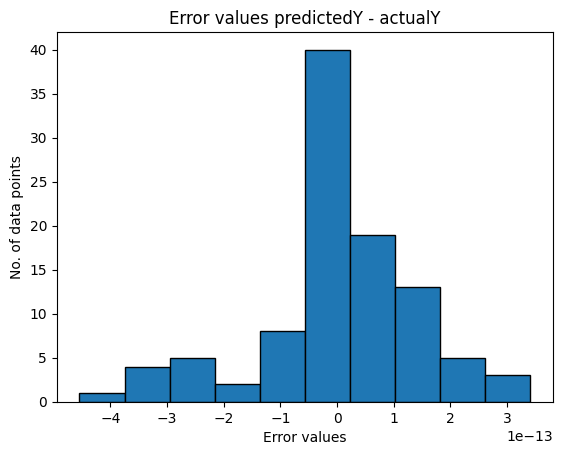

In [13]:
plt.hist(error_vector,edgecolor='black')
plt.title("Error values predictedY - actualY")
plt.xlabel("Error values")
plt.ylabel("No. of data points")
plt.show()

# Applying Gradient Descent, Accelerated Gradient Descent and Stochastic Gradient Descent for 1000 steps

- Creating a function to calculate the Gradient Descent

In [14]:
def grad_descent(w,lr,itr): #to compute gradient descent
        w_new=w.copy()
        cst=0
        for i in range(itr):
            cost_gd.append(cost(w_new))
            error_wgd.append(np.sum(np.abs(w_new-w_star)))
            eval_gd.append(cst)
            w_new-=lr*grad(w_new)
            cst+=len(Y)
        return w_new

In [15]:
cost_gd=[]
error_wgd=[]
eval_gd=[]
w_gd=grad_descent(np.zeros_like(Phi.columns),1.925e-6,1000)

In [16]:
cost_gd[-1]

0.017415684294533326

In [17]:
w_gd

array([-0.030812671622336665, 0.0006300851950317492, 4.999263866054947,
       0.0009798205890864115, 0.00016491378340228124, -1.9998305646899006,
       -9.655826661003358e-07, 6.999995409710184, 6.505160942426197e-05,
       0.0002342826129169036, -8.380854362524917e-05,
       -1.1194839385362249e-05, 0.00028679277421198544,
       16.000016238640267, 0.00025844065878926844], dtype=object)

In [18]:
def accl_grad_descent(w,itr=1000,lr=1e-5,beta_2=0.5):
    y=w.copy()
    w_new=w.copy()
    cst=0
    # beta_2=((k**0.5)-1)/((k**0.5)+1)
    for i in range(itr):
        cost_agd.append(cost(w_new))
        error_wagd.append(np.sum(np.abs(w_new-w_star)))
        eval_agd.append(cst)
        y_old=y.copy()
        y=w_new-lr*grad(w_new)
        w_new=(1+beta_2)*y - beta_2*y_old
        cst+=len(Y)
    return w_new

In [19]:
cost_agd=[]
error_wagd=[]
eval_agd=[]
accl_grad_descent(np.zeros_like(Phi.columns),lr=1.2263e-6,beta_2=0.8,itr=1000)#lr=1.2263e-6 gave good results

array([-0.0270903412395301, 7.943659243428082e-05, 4.999915871551714,
       0.00036656453885344504, 0.0001398688472160275, -1.9998526512002686,
       3.6214413498581596e-05, 6.99995898081997, 7.184647473455473e-05,
       0.0001662214247686411, -1.9896093436073417e-05,
       -2.1152524010201746e-05, 0.0002347765103087181, 16.000007250912603,
       0.00020140723991163246], dtype=object)

In [20]:
cost_agd[-1]

0.01131506129118991

In [161]:
def stoch_grad_descent(w,k,itr):
    w_new=w.copy()
    cst=0
    for i in range(itr):
        cost_sgd.append(cost(w_new))
        error_wsgd.append(np.sum(np.abs(w_new-w_star)))
        eval_sgd.append(cst)
        rand=np.random.randint(0,len(Y))
        gradient=2*Phi.values[rand]*(Phi.values[rand]@w_new-Y[rand])
        lr= k * (0.99 ** (i // 10)) * 1.1 **(i//100)
        w_new=w_new-lr*gradient
        cst+=1
    return w_new

In [239]:
cost_sgd=[]
error_wsgd=[]
eval_sgd=[]
stoch_grad_descent(np.zeros_like(Phi.columns),4.4e-5,1000)

array([-0.06430014921880925, 0.035134297971976376, 4.836225622003946,
       -0.5253761957986867, -0.0018307018750647651, -1.9929645297202123,
       0.048441822539063296, 7.026511178311284, -0.008496631606449027,
       -0.0027617577799416227, -0.047110470886759764,
       0.017008652513301515, 0.028026425020335796, 16.01617682549478,
       -0.012022222501540886], dtype=object)

In [240]:
cost_sgd[-1]

1600.898611439588

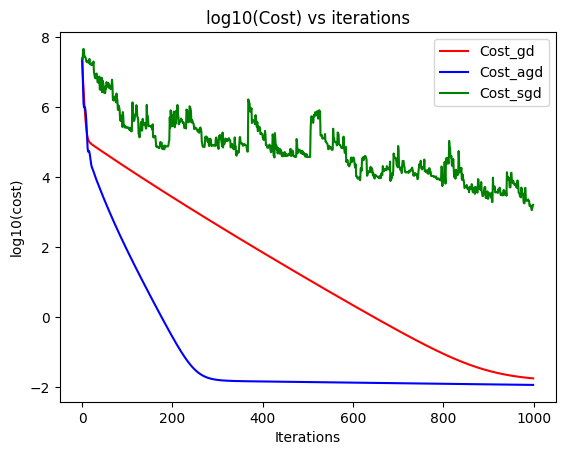

In [241]:
plt.plot(np.array([_ for _ in range(1000)]),np.log10(cost_gd),color='red',label='Cost_gd')
plt.plot(np.array([_ for _ in range(1000)]),np.log10(cost_agd),color='blue',label='Cost_agd')
plt.plot(np.array([_ for _ in range(1000)]),np.log10(cost_sgd),color='green',label='Cost_sgd')
plt.xlabel("Iterations")
plt.ylabel("log10(cost)")
plt.title("log10(Cost) vs iterations")
plt.legend()
plt.show()

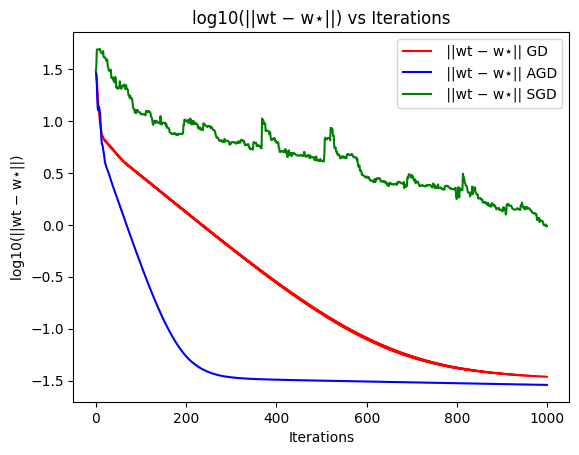

In [242]:
plt.plot(np.array([_ for _ in range(1000)]),np.log10(error_wgd),color='red',label=' ||wt − w⋆|| GD')
plt.plot(np.array([_ for _ in range(1000)]),np.log10(error_wagd),color='blue',label=' ||wt − w⋆|| AGD')
plt.plot(np.array([_ for _ in range(1000)]),np.log10(error_wsgd),color='green',label=' ||wt − w⋆|| SGD')
plt.title("log10(||wt − w⋆||) vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("log10(||wt − w⋆||)")
plt.legend()
plt.show()

# Plotting the log10(cost) and log10(||wt − w⋆||) vs Gradient Evaluations for the first 1000 gradient calculations
- Total gradient evaluations for sgd in 1000 epochs=1,000
- Total gradient evaluations for agd and gd in 1000 epochs=100,000

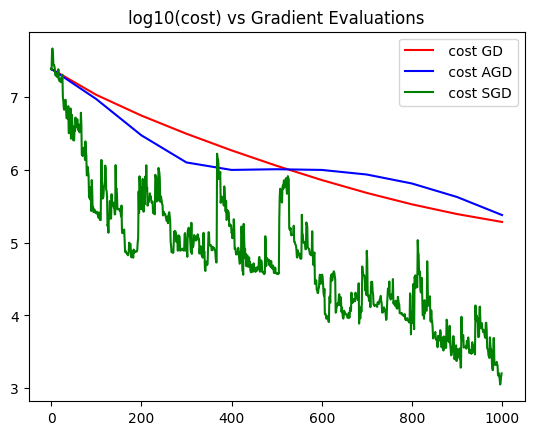

In [243]:
plt.plot(eval_gd[:11],np.log10(cost_gd[:11]),color='red',label=' cost GD')
plt.plot(eval_agd[:11],np.log10(cost_agd[:11]),color='blue',label=' cost AGD')
plt.plot(eval_sgd,np.log10(cost_sgd),color='green',label=' cost SGD')
plt.title("log10(cost) vs Gradient Evaluations")
plt.legend()
plt.show()

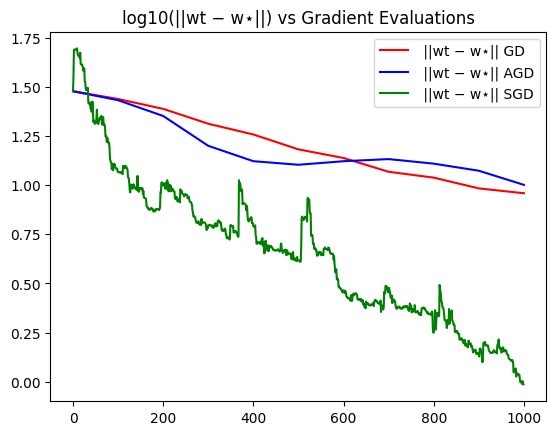

In [244]:
plt.plot(eval_gd[:11],np.log10(error_wgd[:11]),color='red',label=' ||wt − w⋆|| GD')
plt.plot(eval_agd[:11],np.log10(error_wagd[:11]),color='blue',label=' ||wt − w⋆|| AGD')
plt.plot(eval_sgd,np.log10(error_wsgd),color='green',label=' ||wt − w⋆|| SGD')
plt.title("log10(||wt − w⋆||) vs Gradient Evaluations")
plt.legend()
plt.show()

# Plotting the log10(cost) and ||wt − w⋆|| vs Gradient Evaluations for all gradient evaluations

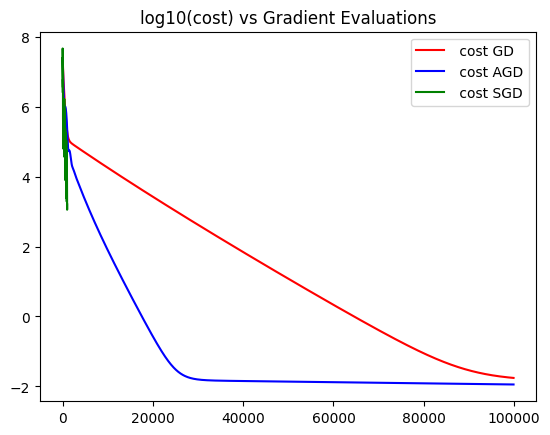

In [245]:
plt.plot(eval_gd,np.log10(cost_gd),color='red',label=' cost GD')
plt.plot(eval_agd,np.log10(cost_agd),color='blue',label=' cost AGD')
plt.plot(eval_sgd,np.log10(cost_sgd),color='green',label=' cost SGD')
plt.title("log10(cost) vs Gradient Evaluations")
plt.legend()
plt.show()

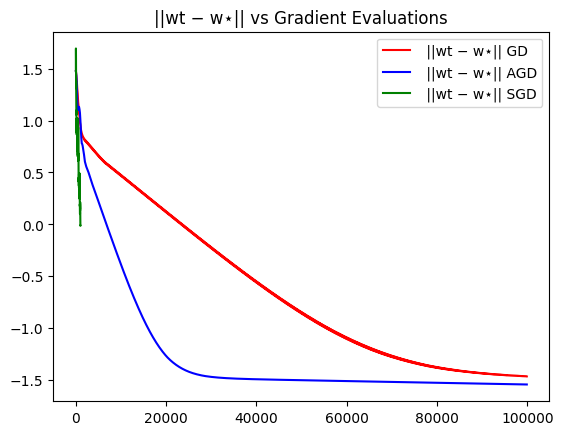

In [246]:
plt.plot(eval_gd,np.log10(error_wgd),color='red',label=' ||wt − w⋆|| GD')
plt.plot(eval_agd,np.log10(error_wagd),color='blue',label=' ||wt − w⋆|| AGD')
plt.plot(eval_sgd,np.log10(error_wsgd),color='green',label=' ||wt − w⋆|| SGD')
plt.title("||wt − w⋆|| vs Gradient Evaluations")
plt.legend()
plt.show()

- Trying sgd for 10,000 epochs

In [221]:
cost_sgd=[]
error_wsgd=[]
eval_sgd=[]
stoch_grad_descent(np.zeros_like(Phi.columns),4.4e-5,10000)

array([-0.12477524701984134, 0.000699908976842163, 4.999809360005518,
       0.0013424186899776529, 0.0008645178879248569, -1.9991275873231475,
       0.0003725642792592695, 7.000445636834818, 0.00041423896428563034,
       0.0010109372522505667, 5.493796012616386e-05,
       -0.00020886870947957884, 0.00064676697114812, 15.999799414582062,
       0.0007855408179811763], dtype=object)

In [222]:
cost_sgd[-1]

0.34653994517452014

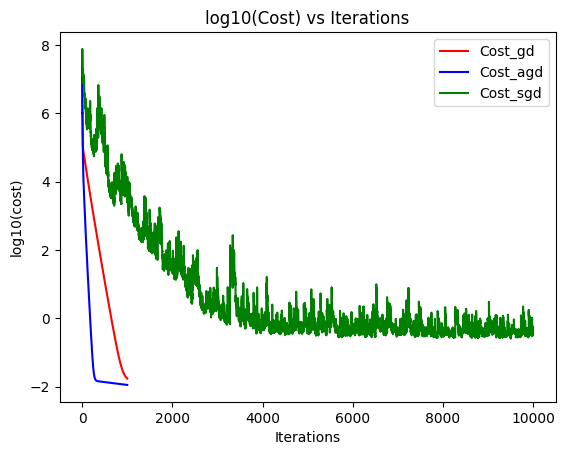

In [223]:
plt.plot(np.array([_ for _ in range(1000)]),np.log10(cost_gd),color='red',label='Cost_gd')
plt.plot(np.array([_ for _ in range(1000)]),np.log10(cost_agd),color='blue',label='Cost_agd')
plt.plot(np.array([_ for _ in range(10000)]),np.log10(cost_sgd),color='green',label='Cost_sgd')
plt.xlabel("Iterations")
plt.ylabel("log10(cost)")
plt.title("log10(Cost) vs Iterations")
plt.legend()
plt.show()

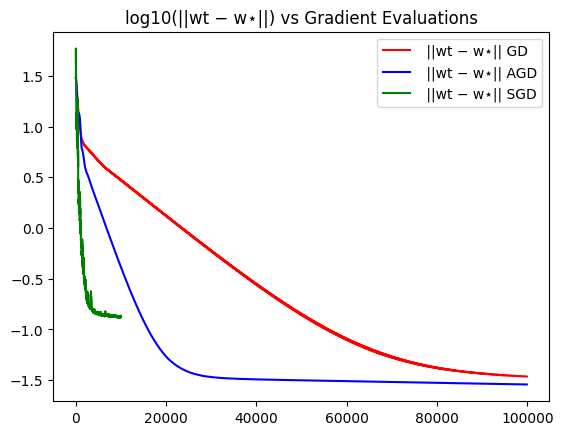

In [224]:
plt.plot(eval_gd,np.log10(error_wgd),color='red',label=' ||wt − w⋆|| GD')
plt.plot(eval_agd,np.log10(error_wagd),color='blue',label=' ||wt − w⋆|| AGD')
plt.plot(eval_sgd,np.log10(error_wsgd),color='green',label=' ||wt − w⋆|| SGD')
plt.title("log10(||wt − w⋆||) vs Gradient Evaluations")
plt.legend()
plt.show()

# Solving using only the first 10 datapoints and qp solver

In [204]:
w_star10=qp(Phi[:10],Y[:10])

Optimal weights: [-21.3701499    2.43334823  15.09084651  26.28073028  -9.24813815
  -1.44964796   0.35229426   4.52413871  -2.83431712  -1.41100335
   3.9431795    1.8705336    3.05018042   9.79026141  -1.62628799]

Polynomial: y(x) = -21.370*1 + 2.433*x1 + 15.091*x2 + 26.281*x3 + -9.248*x4 + -1.450*x1*x1 + 0.352*x1*x2 + 4.524*x1*x3 + -2.834*x1*x4 + -1.411*x2*x2 + 3.943*x2*x3 + 1.871*x2*x4 + 3.050*x3*x3 + 9.790*x3*x4 + -1.626*x4*x4


In [205]:
error_10=Y-Phi@w_star10

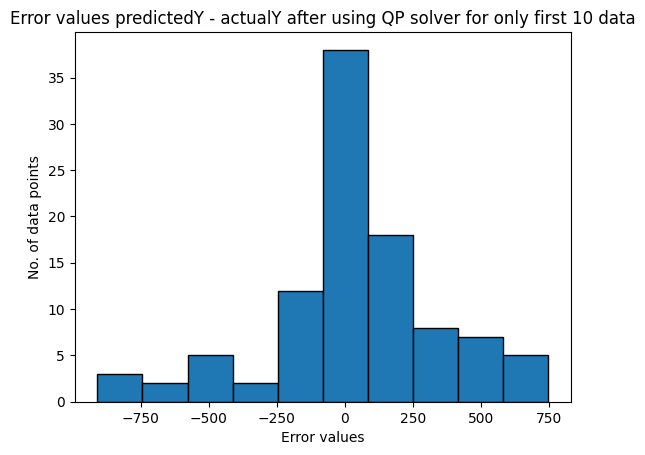

In [206]:
plt.hist(error_10,edgecolor='black')
plt.xlabel("Error values")
plt.ylabel("No. of data points")
plt.title("Error values predictedY - actualY after using QP solver for only first 10 data")
plt.show()

# Including the lasso regularization, and solving using the QP solver

In [207]:
def qp_regularised(X_data,Y_data,lda=0.1):
    #decision variable
    w = cp.Variable(15)
    # pbjective=minimizing squared error ||Xw - y||^2 + lambda * ||w||
    objective = cp.Minimize(cp.sum_squares(X_data.values @ w - Y_data)+lda*cp.norm(w,1))
    #no constraints
    constraints = []
    #solving the QP
    prob = cp.Problem(objective, constraints)
    prob.solve()
    # Optimal weights
    w_star = w.value
    print("Optimal weights:", w_star)
    print(f"Polynomial: y(x) = ",end="")
    x_names=Phi.columns
    for i in range(len(w_star)):
        if (i==len(w_star)-1):
            print(f"{w_star[i]:.3f}*{x_names[i]}")
        else:
            print(f"{w_star[i]:.3f}*{x_names[i]} + ",end="")
    return w_star

- Applying regularization with the reg. parameter=0.3

In [208]:
w_star_reg=qp_regularised(Phi,Y,lda=0.3)

Optimal weights: [-7.47980965e-05  5.33334046e-06  4.99994365e+00  6.33627806e-06
 -5.50209382e-06 -1.99999761e+00 -1.84131995e-06  6.99999900e+00
  1.92892406e-07 -1.50161696e-07 -2.83918564e-06  1.34679658e-06
  5.45153723e-07  1.59999969e+01  8.86419188e-07]
Polynomial: y(x) = -0.000*1 + 0.000*x1 + 5.000*x2 + 0.000*x3 + -0.000*x4 + -2.000*x1*x1 + -0.000*x1*x2 + 7.000*x1*x3 + 0.000*x1*x4 + -0.000*x2*x2 + -0.000*x2*x3 + 0.000*x2*x4 + 0.000*x3*x3 + 16.000*x3*x4 + 0.000*x4*x4


In [209]:
cost(w_star_reg)

9.400674490387696e-06

- Applying regularization with the reg. parameter=0.6

In [211]:
w_star_reg=qp_regularised(Phi,Y,lda=0.6)

Optimal weights: [-1.18830818e-04  1.05636873e-05  4.99988739e+00  1.22377254e-05
 -1.11486576e-05 -1.99999538e+00 -3.72279178e-06  6.99999805e+00
  3.04324469e-07 -4.89837229e-07 -5.65421754e-06  2.71705498e-06
  8.24618712e-07  1.59999938e+01  1.54363540e-06]
Polynomial: y(x) = -0.000*1 + 0.000*x1 + 5.000*x2 + 0.000*x3 + -0.000*x4 + -2.000*x1*x1 + -0.000*x1*x2 + 7.000*x1*x3 + 0.000*x1*x4 + -0.000*x2*x2 + -0.000*x2*x3 + 0.000*x2*x4 + 0.000*x3*x3 + 16.000*x3*x4 + 0.000*x4*x4


In [212]:
cost(w_star_reg)

3.747252840613811e-05

In [213]:
w_star

array([-2.54481567e-14, -1.53512175e-15,  5.00000000e+00, -4.49953649e-15,
       -2.98327315e-15, -2.00000000e+00, -6.15005039e-16,  7.00000000e+00,
        2.69593679e-16,  8.29869247e-17,  5.80144935e-16, -7.97305034e-16,
        1.56242007e-16,  1.60000000e+01,  2.45765767e-16])

### The Difference ($w^*$ vs $w^*_{reg}$)
The coefficients in $w^*_{reg}$ are "shrunken" towards zero compared to $w^*$. This reduces the model's variance and helps prevent overfitting, though it may introduce a slight bias.

- The real difference between w*reg and w* can be seen when both of them are applied to only the first 10 datapoints

In [216]:
w_star10_reg=qp_regularised(Phi[:10],Y[:10],lda=0.3)

Optimal weights: [ 2.93466323e-06 -2.32200337e-04  4.99484627e+00  1.33450793e-04
  3.15034744e-05 -2.00011711e+00  2.19766384e-04  7.00034854e+00
  1.60703358e-05  4.51107687e-04 -1.14458049e-04 -1.69832953e-04
 -5.24409904e-05  1.60000151e+01  2.69658533e-04]
Polynomial: y(x) = 0.000*1 + -0.000*x1 + 4.995*x2 + 0.000*x3 + 0.000*x4 + -2.000*x1*x1 + 0.000*x1*x2 + 7.000*x1*x3 + 0.000*x1*x4 + 0.000*x2*x2 + -0.000*x2*x3 + -0.000*x2*x4 + -0.000*x3*x3 + 16.000*x3*x4 + 0.000*x4*x4


In [217]:
cost(w_star10_reg)

0.16070161788501744

In [218]:
cost(w_star10)

9509229.015736284

- We can clearly see, that w_star regularised fits much better to the overall data, as compared to w_star.
- It is because, when the problem statement is unregularised, it tends to overfit on the training data and does not fit on the unseen ones.
- Hence, regularisation reduces the model's variance.